## Run Simulated Defense

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import optuna
import jax
import jax.numpy as jnp
import optuna
import json
from functools import partial
from jax import jit, vmap, vmap
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

In [2]:
import sys
from pathlib import Path
# Add project root to path for imports
ROOT = Path.cwd().parent  
sys.path.append(str(ROOT))

from src.gradient_flows.potentials import params as default_params
from src.gradient_flows.optimize import objective, load_data_slice, calculate_losses
from src.data_io.maps import load_maps_npz
from src.gradient_flows.utils import extract_quality_trajectories, parse_df_row, prepare_play_data
from src.gradient_flows.viz_tools import run_simulation, create_interactive_plot, plot_speed_analysis

In [3]:
%load_ext autoreload
%autoreload 2

## Run Functions

In [4]:
df = pd.read_parquet("../data/processed/def_features_test/defense_01.18.2016.GSW.at.CLE_21500622.parquet")

In [ ]:
STUDY_NAME = "nba-defensive-optimization-v6-final"
STORAGE_NAME = f"sqlite:///{STUDY_NAME}.db"
study = optuna.load_study(study_name=STUDY_NAME, storage=STORAGE_NAME)

target_trial_number = 1
best_trial = None
for trial in study.trials:
    if trial.number == target_trial_number:
        best_trial = trial
        break

print(f"--- Loaded Trial {best_trial.number} ---")
print(f"Scores -> Pressure: {best_trial.values[0]:.3f}, Smoothness: {best_trial.values[1]:.3f}")

# 3. Apply the fixed IST params that weren't searched by Optuna
best_params = best_trial.params
best_params.update({
    'ist_q_exp': 2.1631, 
    'ist_o_exp': 1.0313,
    'court_dims': [[0., 94.], [0., 50.]],
    'acceleration_penalty_weight': 0.0,    
    'jko_lambda': 0.5,             
    'sinkhorn_epsilon': 0.05,       
    'max_gradient_norm': 0.25, 
    'sprint_penalty_weight': 2.0,
    'max_gradient_norm': 100.0,  # Let the gradient be huge (was 0.25)
    'learning_rate': 1.0,        # Take massive steps (was 0.01)
})

--- Loaded Trial 1 ---
Scores -> Pressure: 4.230, Smoothness: 0.022


In [6]:
#solver_params['cushion_distance'] = 4.5
#solver_params['acceleration_penalty_weight'] = 200.0
#solver_params['sinkhorn_epsilon'] = 0.25
#solver_params['sprint_penalty_weight'] = 1.2
#solver_params['jko_lambda'] = 0.4
#solver_params['acceleration_penalty_weight'] = 50.0

In [7]:
def get_court_shapes_plotly():
    """Returns standard NBA court lines for Plotly."""
    shapes = [
        dict(type="rect", x0=0, y0=0, x1=94, y1=50, line=dict(color="black", width=2)),
        dict(type="line", x0=47, y0=0, x1=47, y1=50, line=dict(color="black", width=2)),
        dict(type="circle", x0=4.5, y0=24.25, x1=6, y1=25.75, line=dict(color="black", width=2)),
        dict(type="circle", x0=94-6, y0=24.25, x1=94-4.5, y1=25.75, line=dict(color="black", width=2))
    ]
    r = 23.75
    shapes.extend([
        dict(type="path", path=f"M {r+5.25},47.5 A {r},{r} 0 0,0 {r+5.25},2.5", line=dict(color="black", width=2)),
        dict(type="path", path=f"M {94-(r+5.25)},47.5 A {r},{r} 0 0,1 {94-(r+5.25)},2.5", line=dict(color="black", width=2)),
        dict(type="line", x0=5.25, y0=2.5, x1=5.25+r, y1=2.5, line=dict(color="black", width=2)),
        dict(type="line", x0=5.25, y0=47.5, x1=5.25+r, y1=47.5, line=dict(color="black", width=2)),
        dict(type="line", x0=94-5.25, y0=2.5, x1=94-(r+5.25), y1=2.5, line=dict(color="black", width=2)),
        dict(type="line", x0=94-5.25, y0=47.5, x1=94-(r+5.25), y1=47.5, line=dict(color="black", width=2))
    ])
    return shapes

In [8]:
def animate_single_play(off_traj, def_traj, ball_traj, q_traj, d0=18.0, k=0.3, b_floor=0.4):
    """
    Takes pre-extracted trajectory arrays and returns an interactive 
    Plotly animation of the play with IST scores.
    
    Expected shapes:
    - off_traj, def_traj: (frames, 5, 2)
    - ball_traj: (frames, 2)
    - q_traj: (frames, 5)
    """
    pio.renderers.default = "browser" 
    
    num_frames = off_traj.shape[0]

    # --- 1. Calculate IST (Now Including Ball Distance) ---
    
    # A. Defender Openness
    dx = off_traj[:, :, None, 0] - def_traj[:, None, :, 0]
    dy = off_traj[:, :, None, 1] - def_traj[:, None, :, 1]
    distances_to_def = np.sqrt(dx**2 + dy**2)
    openness = np.min(distances_to_def, axis=2) # Nearest defender
    
    # B. Distance to Ball
    dx_ball = off_traj[:, :, 0] - ball_traj[:, None, 0]
    dy_ball = off_traj[:, :, 1] - ball_traj[:, None, 1]
    dist_to_ball = np.sqrt(dx_ball**2 + dy_ball**2)
    
    # Calculate raw decay, then compress it so it never drops below b_floor
    raw_logistic = 1.0 / (1.0 + np.exp(k * (dist_to_ball - d0)))
    b_factor = b_floor + (1.0 - b_floor) * raw_logistic
    
    # C. Final IST Calculation (Q * O * B)
    ist = (q_traj ** 2.16) * (openness ** 1.03) * b_factor

    # --- 2. Build Plotly Figure ---
    fig = go.Figure()

    def get_text_labels(ist_array):
        return [f"<b>{val:.2f}</b>" for val in ist_array]

    # Initial frame traces
    # Trace 0: Defense
    fig.add_trace(go.Scatter(x=def_traj[0, :, 0], y=def_traj[0, :, 1], mode='markers', 
                             marker=dict(color='blue', size=15), name='Defense'))
    # Trace 1: Offense
    fig.add_trace(go.Scatter(x=off_traj[0, :, 0], y=off_traj[0, :, 1], mode='markers+text', 
                             text=get_text_labels(ist[0]), textposition="top center", 
                             marker=dict(color='red', size=15), name='Offense'))
    # Trace 2: Ball
    fig.add_trace(go.Scatter(x=[ball_traj[0, 0]], y=[ball_traj[0, 1]], mode='markers', 
                             marker=dict(color='orange', size=12), name='Ball'))

    # Build animation frames (Added traces mapping for lag-free performance)
    frames = []
    for f in range(num_frames):
        frame_data = [
            go.Scatter(x=def_traj[f, :, 0], y=def_traj[f, :, 1]),
            go.Scatter(x=off_traj[f, :, 0], y=off_traj[f, :, 1], text=get_text_labels(ist[f])),
            go.Scatter(x=[ball_traj[f, 0]], y=[ball_traj[f, 1]])
        ]
        frames.append(go.Frame(data=frame_data, name=str(f), traces=[0, 1, 2]))
        
    fig.frames = frames

    # Animation layout and controls
    fig.update_layout(
        updatemenus=[dict(
            type="buttons",
            showactive=False,
            buttons=[
                dict(label="Play", method="animate", 
                     args=[None, {"frame": {"duration": 50, "redraw": False}, 
                                  "fromcurrent": True, "transition": {"duration": 0}}]),
                dict(label="Pause", method="animate", 
                     args=[[None], {"frame": {"duration": 0, "redraw": False}, 
                                    "mode": "immediate", "transition": {"duration": 0}}])
            ]
        )],
        sliders=[dict(
            steps=[dict(method='animate', 
                        args=[[fr.name], dict(mode='immediate', frame=dict(duration=50, redraw=False), 
                                             transition=dict(duration=0))]) for fr in fig.frames],
            transition=dict(duration=0), x=0, xanchor="left", len=1,
        )],
        title_text="Play Animation with Ball Factor IST",
        shapes=get_court_shapes_plotly(),
        xaxis=dict(range=[0, 94], autorange=False, showgrid=False, zeroline=False),
        yaxis=dict(range=[0, 50], autorange=False, scaleanchor="x", scaleratio=1, showgrid=False, zeroline=False),
        plot_bgcolor="white",
        height=600, width=1000
    )
    
    return fig

In [9]:
def create_interactive_plot(sim_traj, real_traj, ball_traj, offenders_traj):
    """Creates an interactive Plotly figure comparing real vs. simulated defense."""
    pio.renderers.default = "browser"

    fig = make_subplots(rows=1, cols=2, subplot_titles=('Real Defense', 'Simulated (JKO)'))

    # Initial Traces (Exactly as you had them)
    fig.add_trace(go.Scatter(x=real_traj[0, :, 0], y=real_traj[0, :, 1], mode='markers', marker=dict(color='blue', size=15), name='Real Defenders'), row=1, col=1)
    fig.add_trace(go.Scatter(x=offenders_traj[0, :, 0], y=offenders_traj[0, :, 1], mode='markers', marker=dict(color='red', size=15), name='Offenders'), row=1, col=1)
    fig.add_trace(go.Scatter(x=[ball_traj[0, 0]], y=[ball_traj[0, 1]], mode='markers', marker=dict(color='orange', size=12), name='Ball'), row=1, col=1)
    
    fig.add_trace(go.Scatter(x=sim_traj[0, :, 0], y=sim_traj[0, :, 1], mode='markers', marker=dict(color='blue', size=15, opacity=0.6), name='Sim Defenders'), row=1, col=2)
    fig.add_trace(go.Scatter(x=offenders_traj[0, :, 0], y=offenders_traj[0, :, 1], mode='markers', marker=dict(color='red', size=15), showlegend=False), row=1, col=2)
    fig.add_trace(go.Scatter(x=[ball_traj[0, 0]], y=[ball_traj[0, 1]], mode='markers', marker=dict(color='orange', size=12), showlegend=False), row=1, col=2)

    # Create frames WITH explicit trace mapping to fix lag
    frames = []
    for k in range(len(sim_traj)):
        frames.append(go.Frame(
            data=[
                go.Scatter(x=real_traj[k, :, 0], y=real_traj[k, :, 1]),
                go.Scatter(x=offenders_traj[k, :, 0], y=offenders_traj[k, :, 1]),
                go.Scatter(x=[ball_traj[k, 0]], y=[ball_traj[k, 1]]),
                go.Scatter(x=sim_traj[k, :, 0], y=sim_traj[k, :, 1]),
                go.Scatter(x=offenders_traj[k, :, 0], y=offenders_traj[k, :, 1]),
                go.Scatter(x=[ball_traj[k, 0]], y=[ball_traj[k, 1]]),
            ],
            traces=[0, 1, 2, 3, 4, 5], # THIS is what prevents Plotly from lagging
            name=str(k)
        ))
    fig.frames = frames

    # Animation controls (redraw set to False for smoothness)
    fig.update_layout(
        updatemenus=[dict(
            type="buttons",
            buttons=[dict(label="Play", method="animate", args=[None, {"frame": {"duration": 50, "redraw": False}, "fromcurrent": True, "transition": {"duration": 0}}])]
        )],
        sliders=[dict(
            steps=[dict(method='animate', args=[[f.name], dict(mode='immediate', frame=dict(duration=50, redraw=False), transition=dict(duration=0))]) for f in fig.frames],
            transition=dict(duration=0),
            x=0,
            xanchor="left",
            len=1,
        )]
    )

    # Dynamic Half-Court Logic
    start_x = ball_traj[0, 0]
    if start_x < 47:
        x_range = [0, 47]  # Left side of court
    else:
        x_range = [47, 94] # Right side of court

    # General layout
    court_shapes = get_court_shapes_plotly() # Assumes you have this imported
    fig.update_layout(
        title_text="Defensive Simulation vs. Reality",
        shapes=court_shapes
    )
    
    # Apply the half-court crop to both subplots
    fig.update_xaxes(range=x_range, autorange=False)
    fig.update_yaxes(range=[0, 50], autorange=False, scaleanchor="x1", scaleratio=1)

    return fig

In [10]:
def run_simulation_from_row(row, solver_params):
    # 1. Extract Ball
    ball_traj = jnp.stack([jnp.array(row['ball_y_traj']) + 5.25, 
                           jnp.array(row['ball_x_traj']) + 25.0], axis=1)
    
    # 2. Extract Offensive Trajectories and Q-Values
    off_list, q_list = [], []
    for i in range(1, 6):
        pos = jnp.stack([jnp.array(row[f'off{i}_y_traj']) + 5.25, 
                         jnp.array(row[f'off{i}_x_traj']) + 25.0], axis=1)
        off_list.append(pos)
        q_list.append(jnp.array(row[f'off{i}_q_traj']))
        
    off_traj = jnp.stack(off_list, axis=1) 
    q_traj = jnp.stack(q_list, axis=1)     

    if q_traj.shape[0] != off_traj.shape[0]:
        q_traj = jnp.tile(q_traj[0], (off_traj.shape[0], 1))
    
    # 3. Extract Real Defensive Trajectories
    def_list = []
    for i in range(1, 6):
        pos = jnp.stack([jnp.array(row[f'def{i}_y_traj']) + 5.25, 
                         jnp.array(row[f'def{i}_x_traj']) + 25.0], axis=1)
        def_list.append(pos)
    real_def_traj = jnp.stack(def_list, axis=1)

    # ==========================================
    # 4. CALCULATE BASE THREAT (Using ist_q_exp)
    # ==========================================
    ball_expanded = ball_traj[:, None, :] 
    dist_to_ball = jnp.linalg.norm(off_traj - ball_expanded, axis=2)
    k_b, d0_b, b_floor = 0.3, 18.0, 0.4
    b_traj = b_floor + (1.0 - b_floor) * (1.0 / (1.0 + jnp.exp(k_b * (dist_to_ball - d0_b))))
    
    # Extract the Q exponent (defaulting to 1.0 if not found)
    q_exp = solver_params.get('ist_q_exp', 1.0)
    
    # Apply the exponent to the Q-traj!
    raw_weights = (q_traj ** q_exp) * b_traj
    
    # Enforce the floor so they don't abandon players
    base_weights_traj = jnp.maximum(raw_weights, 0.35)  
    
    # 5. Determine Basket Position
    real_def_avg_x = jnp.mean(real_def_traj[:, :, 0]) 
    if real_def_avg_x < 47.0:
        basket_pos = jnp.array([5.25, 25.0])  
    else:
        basket_pos = jnp.array([88.75, 25.0])
        
    # 6. Run Simulation 
    sim_def_traj = run_simulation(
        real_def_traj[0], 
        ball_traj,
        off_traj,
        base_weights_traj,
        basket_pos=basket_pos,
        params=solver_params,
        jko_num_steps=20
    )
    
    # ==========================================
    # 7. CALCULATE DISPLAY IST (Using ist_o_exp)
    # ==========================================
    off_expanded = off_traj[:, :, None, :]         
    sim_def_expanded = sim_def_traj[:, None, :, :] 
    
    pairwise_dist = jnp.linalg.norm(off_expanded - sim_def_expanded, axis=-1)
    nearest_sim_def_dist = jnp.min(pairwise_dist, axis=2) 
    
    # Create the dynamic openness scale
    o_traj_sim = jnp.clip(nearest_sim_def_dist / 6.0, 0.5, 1.5)
    
    # Extract the Openness exponent (defaulting to 1.0 if not found)
    o_exp = solver_params.get('ist_o_exp', 1.0)
    
    # The Final True Optimized IST!
    final_display_ist = base_weights_traj * (o_traj_sim ** o_exp)
    # ==========================================


    pairwise_dist_real = jnp.linalg.norm(off_expanded - real_def_traj[:, None, :, :], axis=-1)
    nearest_real_def_dist = jnp.min(pairwise_dist_real, axis=2)
    o_traj_real = jnp.clip(nearest_real_def_dist / 6.0, 0.5, 1.5)
    final_display_ist_real = base_weights_traj * (o_traj_real ** o_exp)
    
    return sim_def_traj, real_def_traj, ball_traj, final_display_ist, final_display_ist_real,off_traj, basket_pos

In [11]:
def smooth_trajectory(traj, alpha=0.3):
    """
    Applies an Exponential Moving Average (EMA) to smooth out micro-jitters.
    Lower alpha = smoother, but very slightly delayed.
    """
    # Convert JAX array to standard NumPy array for easy processing
    traj = np.array(traj) 
    smoothed = np.zeros_like(traj)
    smoothed[0] = traj[0] 
    
    for t in range(1, len(traj)):
        smoothed[t] = alpha * traj[t] + (1 - alpha) * smoothed[t-1]
        
    return smoothed

In [14]:
play = df.iloc[21]
shot_frame = play['local_release_idx']

sim_def_traj, real_def_traj, ball_traj, offender_weights_traj, offender_weights_traj_real, off_traj, basket_pos = run_simulation_from_row(play, best_params)
offender_weights_traj = offender_weights_traj.at[shot_frame:].set(0.1)

smoothed_sim_def_traj = smooth_trajectory(sim_def_traj, alpha=0.3)
animate_single_play(off_traj, smoothed_sim_def_traj, ball_traj, offender_weights_traj)

Saved speed analysis plot to speed_analysis.png


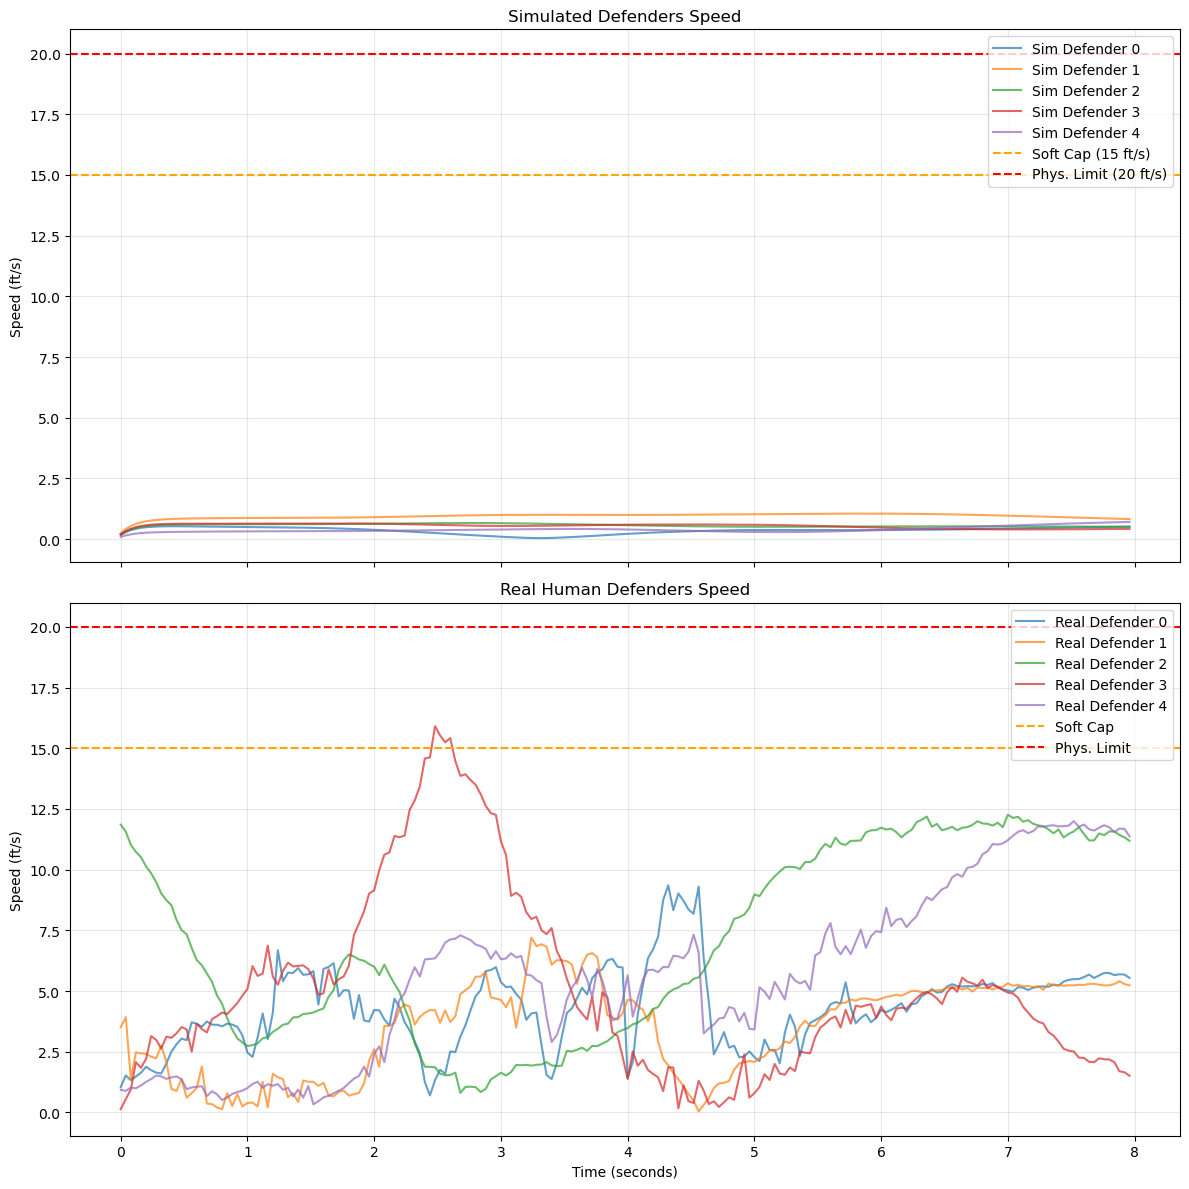

In [15]:
plot_speed_analysis(smoothed_sim_def_traj, real_def_traj)

In [17]:
offender_weights_traj.sum(axis=1).sum()

Array(287.80307, dtype=float32)

In [18]:
offender_weights_traj_real.sum(axis=1).sum()

Array(524.42664, dtype=float32)

In [16]:
best_params

{'max_acceleration': 66.46541977685041,
 'velocity_cap': 15.10252195887764,
 'learning_rate': 0.010970792221301809,
 'jko_num_steps': 39,
 'cushion_dist': 3.416073538915497,
 'attraction_weight': 16.701332166496822,
 'field_weight': -36.423782594099606,
 'basket_gravity_weight': 13.389287072511634,
 'global_ball_weight': 0.13967327704292093,
 'sigma_long': 9.806720045142761,
 'sigma_wide': 2.0346335045123918,
 'lane_blocking_weight': 42.84378387749307,
 'occupancy_weight': 36.91579185981819,
 'cohesion_weight': 0.3901062870704093,
 'formation_radius': 16.125204485317315,
 'ist_q_exp': 2.1631,
 'ist_o_exp': 1.0313,
 'court_dims': [[0.0, 94.0], [0.0, 50.0]],
 'acceleration_penalty_weight': 0.0,
 'jko_lambda': 0.5,
 'sinkhorn_epsilon': 0.05,
 'max_gradient_norm': 0.25,
 'sprint_penalty_weight': 2.0}